# Notebook: Exploratory Data Analysis
### BTT Northstar: Minh Le, Athena Tian, Rianna Lei

---

## I. Load Packages and Data

In [1]:
# Import packages
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sn
import os

In [2]:
train = pd.read_csv('../data/train.csv')
sample_submission = pd.read_csv('../data/sample_submission.csv')
meta = pd.read_csv('../data/metaData.csv')
test = pd.read_csv('../data/test.csv')

In [3]:
# Basic shapes
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)
print("Metadata shape:", meta.shape)

Train shape: (221, 37)
Test shape: (95, 35)
Sample submission shape: (95, 5)
Metadata shape: (37, 6)


In [4]:
# Missing values
print("\nMissing values in train:")
print(train.isna().sum().sort_values(ascending=False).head(10))

print("\nMissing values in test:")
print(test.isna().sum().sort_values(ascending=False).head(10))


Missing values in train:
event_id                     0
dist_min_ci_0_5h             0
dist_change_ci_0_5h          0
dist_slope_ci_0_5h           0
closing_speed_m_per_h        0
closing_speed_abs_m_per_h    0
projected_advance_m          0
dist_accel_m_per_h2          0
dist_fit_r2_0_5h             0
alignment_cos                0
dtype: int64

Missing values in test:
event_id                     0
dist_accel_m_per_h2          0
dist_std_ci_0_5h             0
dist_change_ci_0_5h          0
dist_slope_ci_0_5h           0
closing_speed_m_per_h        0
closing_speed_abs_m_per_h    0
projected_advance_m          0
dist_fit_r2_0_5h             0
spread_bearing_cos           0
dtype: int64


In [5]:
# Split groups
event_df = train[train["event"] == 1].copy()
censored_df = train[train["event"] == 0].copy()

print("Event fires:", len(event_df))
print("Censored fires:", len(censored_df))

Event fires: 69
Censored fires: 152


In [6]:
# Compare means
feature_cols = [c for c in train.columns if c not in ["event_id", "time_to_hit_hours", "event"]]

print("Total features:", len(feature_cols))

rows = []
for col in feature_cols:
    m1 = event_df[col].mean()
    m0 = censored_df[col].mean()
    s1 = event_df[col].std(ddof=1)
    s0 = censored_df[col].std(ddof=1)

    pooled = np.sqrt(((len(event_df)-1)*(s1**2) + (len(censored_df)-1)*(s0**2)) / (len(event_df)+len(censored_df)-2))
    cohens_d = (m1 - m0) / pooled if pooled > 0 else np.nan

    rows.append({
        "feature": col,
        "event_mean": m1,
        "censored_mean": m0,
        "cohens_d": cohens_d,
        "abs_d": abs(cohens_d)
    })

effect_df = pd.DataFrame(rows).sort_values("abs_d", ascending=False)

print("\nTop separating features:")
effect_df.head(15)

Total features: 34

Top separating features:


,feature,event_mean,censored_mean,cohens_d,abs_d
18,dist_min_ci_0_5h,2285.818350,179832.303100,-1.179779,1.179779
2,low_temporal_resolution_0_5h,0.478261,0.842105,-0.880116,0.880116
0,num_perimeters_0_5h,3.478261,1.421053,0.856888,0.856888
1,dt_first_last_0_5h,1.888304,0.567487,0.810366,0.810366
28,alignment_abs,0.342901,0.095443,0.800320,0.800320
17,spread_bearing_cos,0.722017,0.966890,-0.733640,0.733640
8,log1p_growth,0.970291,0.125628,0.657543,0.657543
15,spread_bearing_deg,33.206949,4.949425,0.629013,0.629013
9,log_area_ratio_0_5h,0.167423,0.019136,0.506125,0.506125
12,radial_growth_rate_m_per_h,19.815683,2.302374,0.472819,0.472819


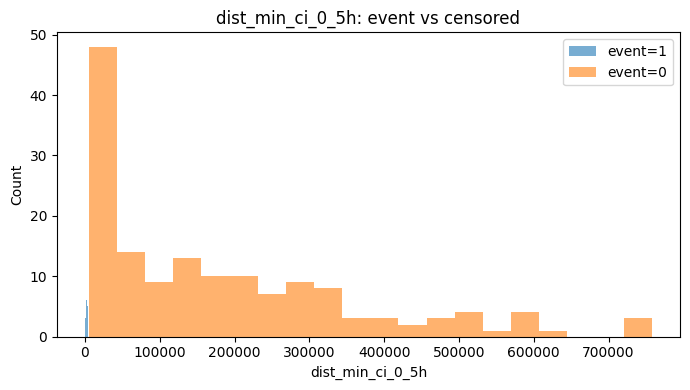

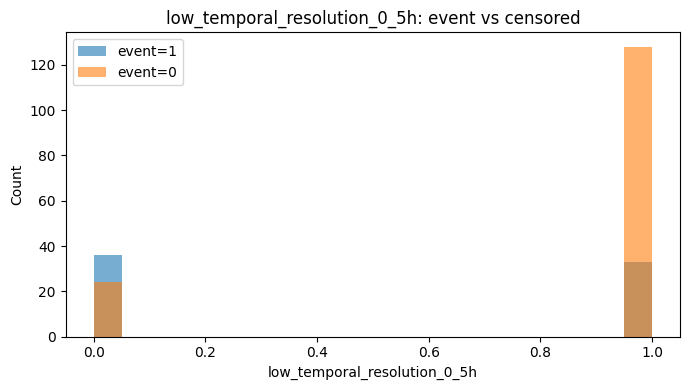

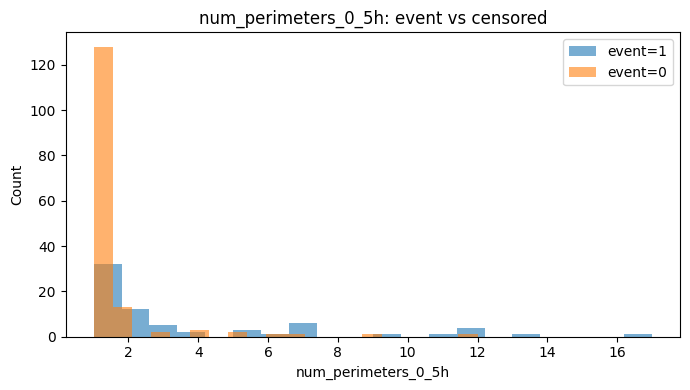

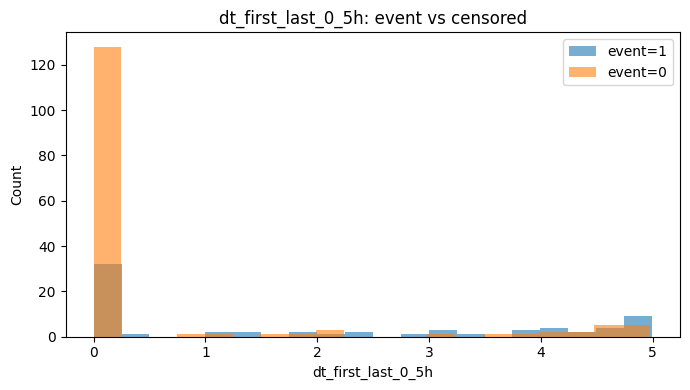

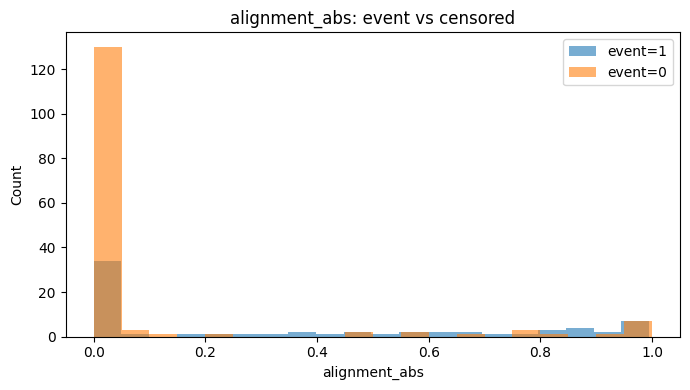

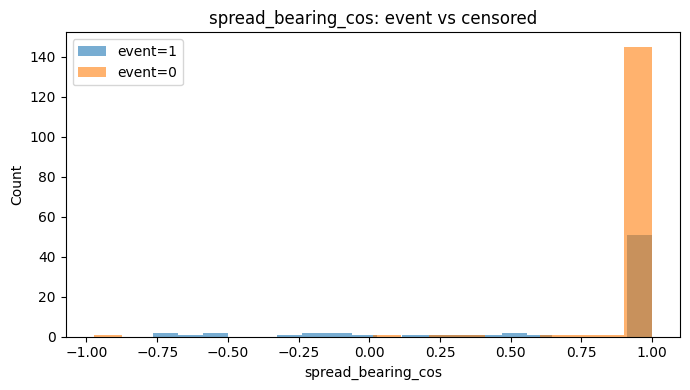

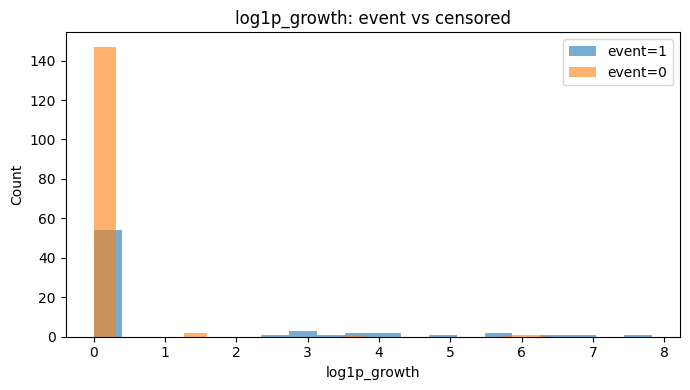

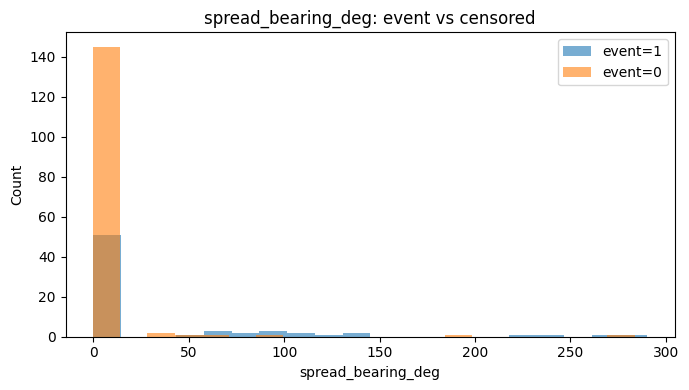

In [7]:
# Plot top 8 separating features
top_features = effect_df.head(8)["feature"].tolist()

for col in top_features:
    plt.figure(figsize=(7,4))
    plt.hist(event_df[col], bins=20, alpha=0.6, label="event=1")
    plt.hist(censored_df[col], bins=20, alpha=0.6, label="event=0")
    plt.title(f"{col}: event vs censored")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:
# Cumulative event counts by horizon
horizons = [12, 24, 48, 72]

timing_rows = []
total_n = len(train)
total_events = int(train["event"].sum())

for h in horizons:
    count_h = ((train["event"] == 1) & (train["time_to_hit_hours"] <= h)).sum()

    timing_rows.append({
        "horizon_hours": h,
        "event_count_by_horizon": int(count_h),
        "pct_of_all_training_rows": count_h / total_n,
        "pct_of_all_event_fires": count_h / total_events
    })

timing_df = pd.DataFrame(timing_rows)
timing_df

,horizon_hours,event_count_by_horizon,pct_of_all_training_rows,pct_of_all_event_fires
0,12,49,0.221719,0.710145
1,24,63,0.285068,0.913043
2,48,66,0.298643,0.956522
3,72,69,0.312217,1.000000


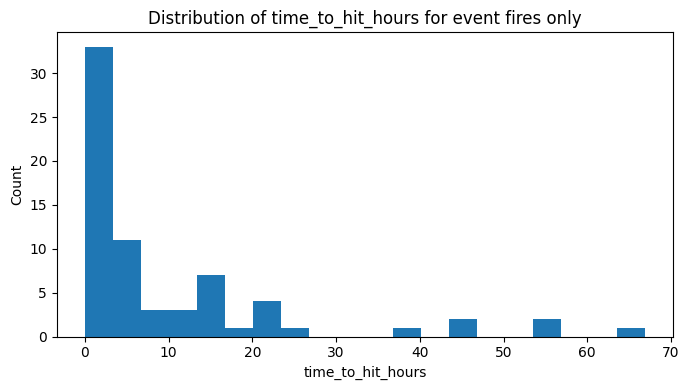

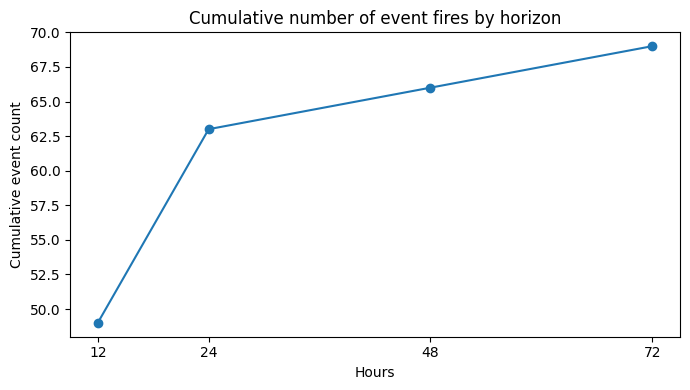

In [9]:
# Histogram of event times only
event_times = train.loc[train["event"] == 1, "time_to_hit_hours"]

plt.figure(figsize=(7,4))
plt.hist(event_times, bins=20)
plt.title("Distribution of time_to_hit_hours for event fires only")
plt.xlabel("time_to_hit_hours")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Simple cumulative curve
cum_counts = [(event_times <= h).sum() for h in horizons]

plt.figure(figsize=(7,4))
plt.plot(horizons, cum_counts, marker="o")
plt.title("Cumulative number of event fires by horizon")
plt.xlabel("Hours")
plt.ylabel("Cumulative event count")
plt.xticks(horizons)
plt.tight_layout()
plt.show()